In [2]:
# import necessary libraries
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error,root_mean_squared_error,r2_score

In [5]:
# load the best model
model = joblib.load("../models/best_model.pkl")
x_train = joblib.load("../models/x_train.pkl")
y_train = joblib.load("../models/y_train.pkl")
x_test = joblib.load("../models/x_test.pkl")
y_test = joblib.load("../models/y_test.pkl")

In [6]:
# make predictions
final_train_pred = model.predict(x_train)
final_test_pred = model.predict(x_test) 

In [7]:
#train set evaluation
rmse = root_mean_squared_error(y_train, final_train_pred)
mae = mean_absolute_error(y_train, final_train_pred)
r2 = r2_score(y_train, final_train_pred)

print("RMSE:", round(rmse, 3))
print("MAE:", round(mae, 3))
print("R2 Score:", round(r2, 3))

RMSE: 36288.786
MAE: 24683.365
R2 Score: 0.901


In [9]:
# test set evaluation
rmse = root_mean_squared_error(y_test,final_test_pred )
mae = mean_absolute_error(y_test, final_test_pred)
r2 = r2_score(y_test, final_test_pred)

print("RMSE:", round(rmse, 3))
print("MAE:", round(mae, 3))
print("R2 Score:", round(r2, 3)) 

RMSE: 47236.403
MAE: 31300.372
R2 Score: 0.83


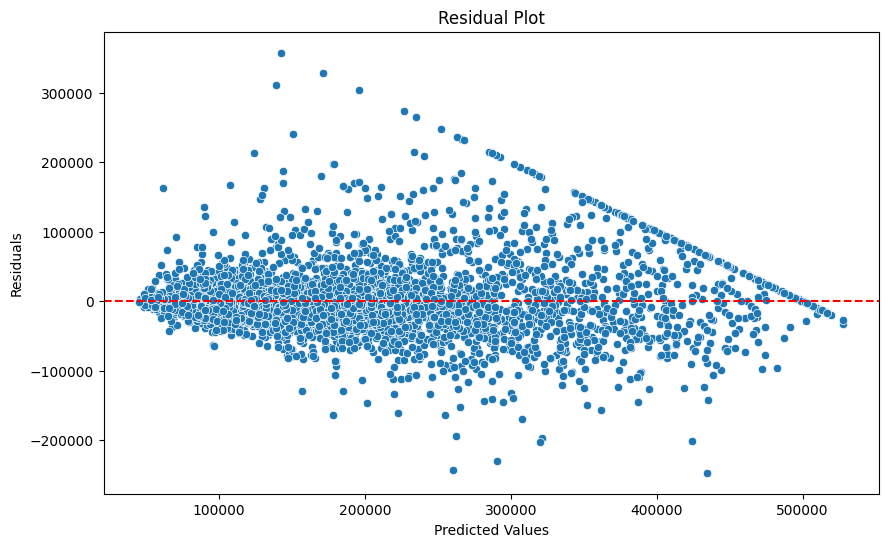

In [10]:
#residual plot
residuals = y_test- final_test_pred

plt.figure(figsize=(10, 6))
sns.scatterplot(x=final_test_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--') 
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

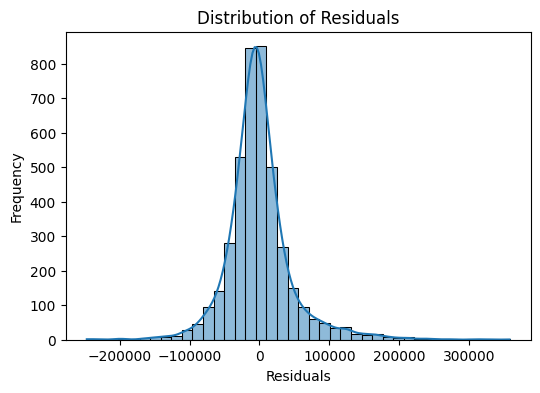

In [12]:
# distribution of residuals
plt.figure(figsize=(6, 4))
sns.histplot(residuals, kde=True, bins=40)
plt.title("Distribution of Residuals")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()